# 📑 Tutorials for PyPOTS Imputation Models
## 📀 Preparing the  **Electricity Transformer Temperature** dataset for this tutorial

In [50]:
from benchpots.datasets import preprocess_ett

# Load the dataset with artificially missing values
ett = preprocess_ett(subset="ETTm1", rate=0.1, n_steps=24)

2025-03-06 18:22:21 [INFO]: You're using dataset electricity_transformer_temperature, please cite it properly in your work. You can find its reference information at the below link: 
https://github.com/WenjieDu/TSDB/tree/main/dataset_profiles/electricity_transformer_temperature
2025-03-06 18:22:21 [INFO]: Dataset electricity_transformer_temperature has already been downloaded. Processing directly...
2025-03-06 18:22:21 [INFO]: Dataset electricity_transformer_temperature has already been cached. Loading from cache directly...
2025-03-06 18:22:21 [INFO]: Loaded successfully!
2025-03-06 18:22:21 [INFO]: months selected as train set are <PeriodArray>
['2016-07', '2016-08', '2016-09', '2016-10', '2016-11', '2016-12', '2017-01',
 '2017-02', '2017-03', '2017-04', '2017-05', '2017-06', '2017-07', '2017-08']
Length: 14, dtype: period[M]
2025-03-06 18:22:21 [INFO]: months selected as val set are <PeriodArray>
['2017-09', '2017-10', '2017-11', '2017-12', '2018-01']
Length: 5, dtype: period[M]
202

In [51]:
ett.keys()

dict_keys(['n_steps', 'n_features', 'scaler', 'train_X', 'val_X', 'test_X', 'train_X_ori', 'val_X_ori', 'test_X_ori'])

In [52]:
# Assemble the datasets for training, validating, and testing.

dataset_for_training = {
    "X": ett['train_X'],
}

dataset_for_validating = {
    "X": ett['val_X'],
    "X_ori": ett['val_X_ori'],
}

dataset_for_testing = {
    "X": ett['test_X'],
    "X_ori": ett['test_X_ori']
}


## División en entrenamiento, validación y testing

This dataset [52] is collected from electricity transformers in two
years from 2016/07/01 to 2018/06/26. Here we select the 15-minute-level version dataset that contains data collected
every 15 minutes and has a total of 69680 sample points without missing values. Each sample has seven features,
including oil temperature and six different types of external power load features. The data in the first four months
(2016/07 - 2016/10) is taken as the test set. The following four-month data (2016/11 - 2017/02) is held out as the
validation set. The left sixteen months (2017/03 - 2018/06) are for training use. The sliding-window method is applied
for time-series sample generation. The window size is set as 6 hours (i.e. 24 consecutive steps) and the sliding size is 3
hours (i.e. 12 steps). Still, 10% of the observed values in the validation set and test set are randomly masked for model
evaluation.

In [54]:
dataset_for_testing['X_ori']

array([[[ 1.5003712 ,  1.3998331 ,  1.4872298 , ...,  0.3811214 ,
         -0.05657961, -1.7077985 ],
        [ 1.348415  ,  1.2751297 ,  1.2653043 , ...,  0.40479606,
         -0.05657961, -1.6749914 ],
        [ 1.337561  ,  1.2125446 ,  1.2772865 , ...,  0.308519  ,
         -0.1010062 , -1.6668189 ],
        ...,
        [ 0.93612415,  0.7118624 ,  0.91748023, ..., -0.05133632,
         -0.23724754, -1.7242603 ],
        [ 0.860146  ,  0.6805698 ,  0.839511  , ...,  0.02047697,
         -0.28167415, -1.7077985 ],
        [ 1.0338105 ,  0.64927715,  0.96540946, ...,  0.02047697,
         -0.23724754, -1.7488948 ]],

       [[ 1.0229564 ,  0.5241067 ,  0.9593339 , ...,  0.11675402,
         -0.23724754, -1.7407223 ],
        [ 0.97954035,  0.14859521,  0.89351577, ...,  0.21303107,
         -0.23724754, -1.7242603 ],
        [ 1.0989345 ,  0.9309108 ,  1.1513882 , ...,  0.2603804 ,
         -0.28167415, -1.7488948 ],
        ...,
        [-2.3733807 ,  0.61798453, -2.680751  , ...,  

In [55]:
dataset_for_testing['X']

array([[[ 1.5003712 ,         nan,  1.4872298 , ...,  0.3811214 ,
         -0.05657961, -1.7077985 ],
        [ 1.348415  ,  1.2751297 ,  1.2653043 , ...,         nan,
                 nan, -1.6749914 ],
        [ 1.337561  ,  1.2125446 ,         nan, ...,  0.308519  ,
         -0.1010062 , -1.6668189 ],
        ...,
        [ 0.93612415,         nan,         nan, ...,         nan,
         -0.23724754, -1.7242603 ],
        [ 0.860146  ,         nan,  0.839511  , ...,  0.02047697,
         -0.28167415, -1.7077985 ],
        [ 1.0338105 ,  0.64927715,  0.96540946, ...,  0.02047697,
         -0.23724754, -1.7488948 ]],

       [[ 1.0229564 ,  0.5241067 ,  0.9593339 , ...,  0.11675402,
         -0.23724754,         nan],
        [ 0.97954035,  0.14859521,  0.89351577, ...,  0.21303107,
         -0.23724754,         nan],
        [        nan,         nan,  1.1513882 , ...,  0.2603804 ,
         -0.28167415, -1.7488948 ],
        ...,
        [-2.3733807 ,  0.61798453, -2.680751  , ...,  

In [57]:
features = {
    "HUFL": None,  # 370 valores aleatorios para HUFL
    "HULL": None,  
    "MUFL": None,  
    "MULL": None,  
    "LUFL": None,  
    "LULL": None,  
    "OT": None,    
}
len(features)

7

In [58]:
import pandas as pd
import numpy as np

# Supongamos que 'dataset_for_testing['X']' es tu numpy array de shape (583, 24, 7)
# Reestructuramos el array para convertirlo en un formato adecuado para series temporales multivariantes
# Transponemos y aplanamos para que tengamos (583 * 24, 7)

X_reshaped = dataset_for_testing['X'].reshape(-1, 7)

# Ahora X_reshaped tiene la forma (583 * 24, 7)

# Creamos un índice para las filas basado en el paso temporal
index = pd.MultiIndex.from_product([range(583), range(24)], names=['Sample', 'Time'])

# Creamos el DataFrame
df = pd.DataFrame(X_reshaped, columns=features, index=index)

# Mostrar las primeras filas del DataFrame
df

HUFL      HULL      MUFL      MULL      LUFL      LULL  \
Sample Time                                                               
0      0     1.500371       NaN  1.487230  1.193077  0.381121 -0.056580   
       1     1.348415  1.275130  1.265304  1.047235       NaN       NaN   
       2     1.337561  1.212545       NaN  0.974570  0.308519 -0.101006   
       3     1.456955  1.462418  1.367238  0.992993  0.308519 -0.056580   
       4     1.446101  1.431126  1.469172  1.193077  0.213031 -0.146914   
...               ...       ...       ...       ...       ...       ...   
582    19   -1.125492  0.837033 -1.247433  0.738153  0.501073  0.845279   
       20   -0.821741       NaN -0.965596  0.683910  0.549212  1.116281   
       21   -0.431159  0.774448 -0.503856  0.574401  0.597350  1.116281   
       22   -0.268348  0.711862 -0.413904  0.538068       NaN  0.935613   
       23   -0.072976  0.711862       NaN  0.574401  0.549212       NaN   

                   OT  
Sample Time            
0      0    -1.707798  
       1    -1.674991  
       2    -1.666819  
       3    -1.666819  
       4    -1.674991  
...               ...  
582    19   -0.812668  
       20   -0.829013  
       21         NaN  
       22   -0.870109  
       23   -0.878282  

[13992 rows x 7 columns]

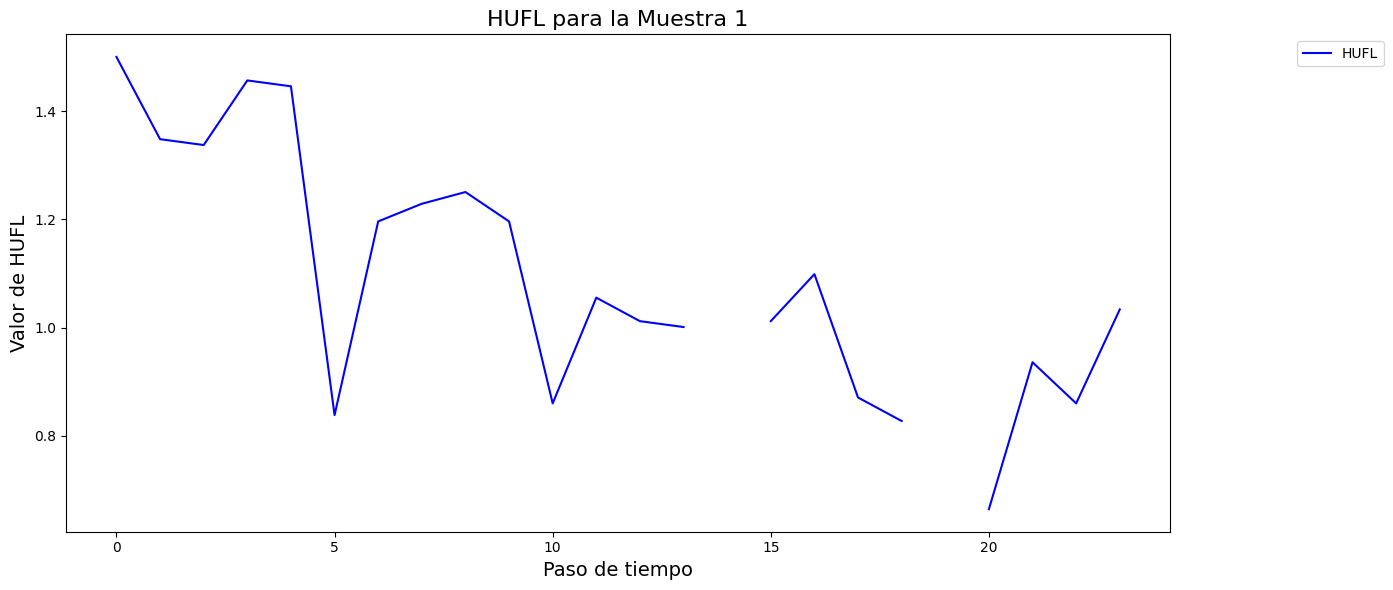

In [59]:
import matplotlib.pyplot as plt

# Seleccionar una muestra específica (por ejemplo, la primera muestra, índice 0)
sample_index = 0
time_steps = range(24)  # 24 pasos de tiempo

# Obtener los datos de la primera muestra para las características específicas
sample_data = df.loc[sample_index, ['HUFL', 'HULL']]

# Crear gráfico para HUFL
plt.figure(figsize=(14, 6))
if sample_data['HUFL'].notna().any():  # Verificar si hay datos válidos
    plt.plot(time_steps, sample_data['HUFL'], label='HUFL', color='b')
    plt.title(f'HUFL para la Muestra {sample_index + 1}', fontsize=16)
    plt.xlabel('Paso de tiempo', fontsize=14)
    plt.ylabel('Valor de HUFL', fontsize=14)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=10)
    plt.tight_layout()
else:
    print("No hay datos válidos para HUFL en la muestra.")



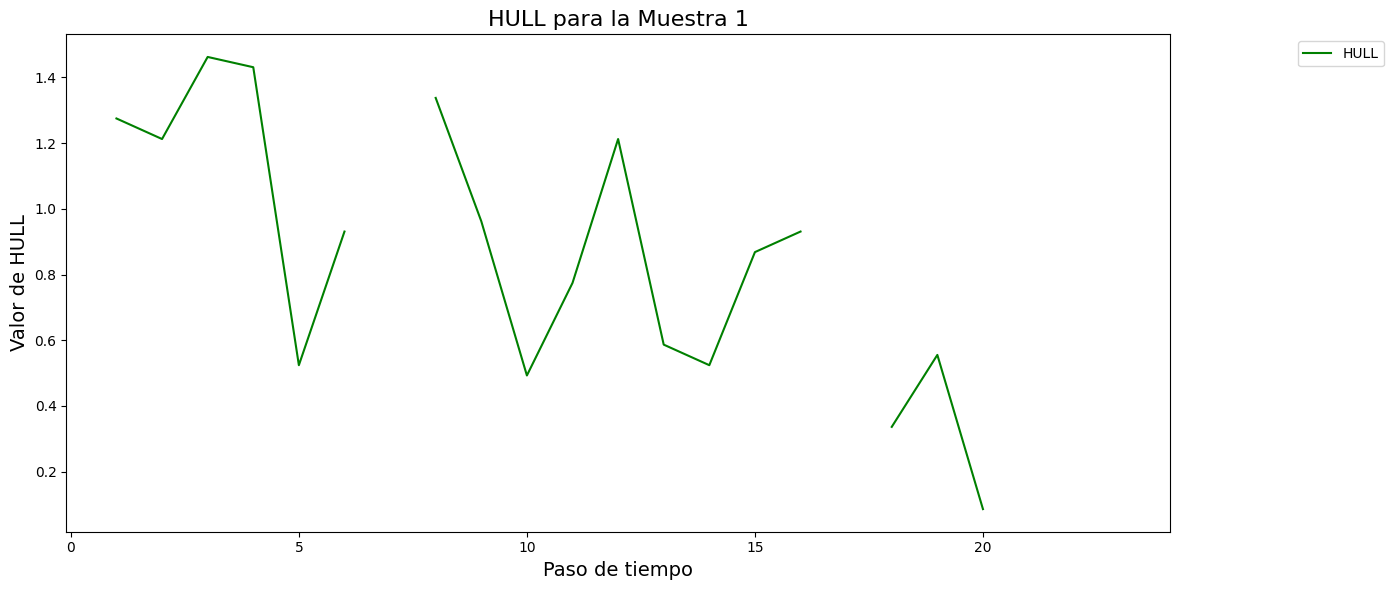

In [60]:
# Crear gráfico para HULL
plt.figure(figsize=(14, 6))
if sample_data['HULL'].notna().any():  # Verificar si hay datos válidos
    plt.plot(time_steps, sample_data['HULL'], label='HULL', color='g')
    plt.title(f'HULL para la Muestra {sample_index + 1}', fontsize=16)
    plt.xlabel('Paso de tiempo', fontsize=14)
    plt.ylabel('Valor de HULL', fontsize=14)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=10)
    plt.tight_layout()
else:
    print("No hay datos válidos para HULL en la muestra.")

# Mostrar los gráficos
plt.show()


In [61]:
ett['n_steps']

24

In [62]:
ett['n_features']

7

## 🚀 An example of **SAITS** for imputation

In [63]:
from pypots.optim import Adam
from pypots.imputation import SAITS

# initialize the model
saits = SAITS(
    n_steps=ett['n_steps'],
    n_features=ett['n_features'],
    n_layers=2,
    d_model=256,
    d_ffn=128,
    n_heads=4,
    d_k=64,
    d_v=64,
    dropout=0.1,
    attn_dropout=0.1,
    ##### Esto diferencia al SAIT del modelo Transformer
    diagonal_attention_mask=True,  # otherwise the original self-attention mechanism will be applied
    ORT_weight=1,  # you can adjust the weight values of arguments ORT_weight
    # and MIT_weight to make the SAITS model focus more on one task. Usually you can just leave them to the default values, i.e. 1.
    MIT_weight=1,
    batch_size=32,
    # here we set epochs=10 for a quick demo, you can set it to 100 or more for better performance
    epochs=10,
    # here we set patience=3 to early stop the training if the evaluting loss doesn't decrease for 3 epoches.
    # You can leave it to defualt as None to disable early stopping.
    patience=3,
    # give the optimizer. Different from torch.optim.Optimizer, you don't have to specify model's parameters when
    # initializing pypots.optim.Optimizer. You can also leave it to default. It will initilize an Adam optimizer with lr=0.001.
    optimizer=Adam(lr=1e-3),
    # this num_workers argument is for torch.utils.data.Dataloader. It's the number of subprocesses to use for data loading.
    # Leaving it to default as 0 means data loading will be in the main process, i.e. there won't be subprocesses.
    # You can increase it to >1 if you think your dataloading is a bottleneck to your model training speed
    num_workers=0,
    # just leave it to default as None, PyPOTS will automatically assign the best device for you.
    # Set it as 'cpu' if you don't have CUDA devices. You can also set it to 'cuda:0' or 'cuda:1' if you have multiple CUDA devices, even parallelly on ['cuda:0', 'cuda:1']
    device=None,  
    # set the path for saving tensorboard and trained model files 
    saving_path="tutorial_results/imputation/saits",
    # only save the best model after training finished.
    # You can also set it as "better" to save models performing better ever during training.
    model_saving_strategy="best",
)


2025-03-06 18:29:39 [INFO]: No given device, using default device: cpu
2025-03-06 18:29:39 [INFO]: Model files will be saved to tutorial_results/imputation/saits/20250306_T182939
2025-03-06 18:29:39 [INFO]: Tensorboard file will be saved to tutorial_results/imputation/saits/20250306_T182939/tensorboard
2025-03-06 18:29:39 [INFO]: SAITS initialized with the given hyperparameters, the number of trainable parameters: 1,327,910


In [64]:
# train the model on the training set, and validate it on the validating set to select the best model for testing in the next step
saits.fit(train_set=dataset_for_training, val_set=dataset_for_validating)


2025-03-06 18:29:45 [INFO]: Epoch 001 - training loss: 0.8215, validation loss: 0.0573
2025-03-06 18:29:49 [INFO]: Epoch 002 - training loss: 0.5582, validation loss: 0.0434
2025-03-06 18:29:54 [INFO]: Epoch 003 - training loss: 0.5017, validation loss: 0.0461
2025-03-06 18:29:59 [INFO]: Epoch 004 - training loss: 0.4601, validation loss: 0.0541
2025-03-06 18:30:03 [INFO]: Epoch 005 - training loss: 0.4262, validation loss: 0.0298
2025-03-06 18:30:08 [INFO]: Epoch 006 - training loss: 0.3733, validation loss: 0.0346
2025-03-06 18:30:12 [INFO]: Epoch 007 - training loss: 0.3463, validation loss: 0.0271
2025-03-06 18:30:17 [INFO]: Epoch 008 - training loss: 0.3132, validation loss: 0.0368
2025-03-06 18:30:21 [INFO]: Epoch 009 - training loss: 0.3032, validation loss: 0.0254
2025-03-06 18:30:26 [INFO]: Epoch 010 - training loss: 0.2870, validation loss: 0.0316
2025-03-06 18:30:26 [INFO]: Finished training. The best model is from epoch#9.
2025-03-06 18:30:26 [INFO]: Saved the model to tuto

In [65]:
# the testing stage, impute the originally-missing values and artificially-missing values in the test set

saits_results = saits.predict(dataset_for_testing)
saits_imputation = saits_results["imputation"]


In [66]:
saits_imputation

array([[[ 1.5003712 ,  1.0972886 ,  1.4872298 , ...,  0.3811214 ,
         -0.05657961, -1.7077985 ],
        [ 1.348415  ,  1.2751297 ,  1.2653043 , ...,  0.47375435,
         -0.02808448, -1.6749914 ],
        [ 1.337561  ,  1.2125446 ,  1.496227  , ...,  0.308519  ,
         -0.1010062 , -1.6668189 ],
        ...,
        [ 0.93612415,  0.43478993,  1.1257403 , ...,  0.14628063,
         -0.23724754, -1.7242603 ],
        [ 0.860146  ,  0.45470095,  0.839511  , ...,  0.02047697,
         -0.28167415, -1.7077985 ],
        [ 1.0338105 ,  0.64927715,  0.96540946, ...,  0.02047697,
         -0.23724754, -1.7488948 ]],

       [[ 1.0229564 ,  0.5241067 ,  0.9593339 , ...,  0.11675402,
         -0.23724754, -1.7089086 ],
        [ 0.97954035,  0.14859521,  0.89351577, ...,  0.21303107,
         -0.23724754, -1.7216756 ],
        [ 1.2682745 ,  0.60641336,  1.1513882 , ...,  0.2603804 ,
         -0.28167415, -1.7488948 ],
        ...,
        [-2.3733807 ,  0.61798453, -2.680751  , ...,  

In [68]:
import pandas as pd
import numpy as np

# Supongamos que 'dataset_for_testing['X']' es tu numpy array de shape (291,100, 370)
# Reestructuramos el array para convertirlo en un formato adecuado para series temporales multivariantes
# Transponemos y aplanamos para que tengamos (583 * 24, 7)

X_reshaped = saits_imputation.reshape(-1, 7)

# Ahora X_reshaped tiene la forma (583 * 24, 7)

# Creamos un índice para las filas basado en el paso temporal
index = pd.MultiIndex.from_product([range(583), range(24)], names=['Sample', 'Time'])

# Creamos el DataFrame
df_imputation = pd.DataFrame(X_reshaped, columns=features, index=index)

# Mostrar las primeras filas del DataFrame
df_imputation

HUFL      HULL      MUFL      MULL      LUFL      LULL  \
Sample Time                                                               
0      0     1.500371  1.097289  1.487230  1.193077  0.381121 -0.056580   
       1     1.348415  1.275130  1.265304  1.047235  0.473754 -0.028084   
       2     1.337561  1.212545  1.496227  0.974570  0.308519 -0.101006   
       3     1.456955  1.462418  1.367238  0.992993  0.308519 -0.056580   
       4     1.446101  1.431126  1.469172  1.193077  0.213031 -0.146914   
...               ...       ...       ...       ...       ...       ...   
582    19   -1.125492  0.837033 -1.247433  0.738153  0.501073  0.845279   
       20   -0.821741  0.864002 -0.965596  0.683910  0.549212  1.116281   
       21   -0.431159  0.774448 -0.503856  0.574401  0.597350  1.116281   
       22   -0.268348  0.711862 -0.413904  0.538068  0.571967  0.935613   
       23   -0.072976  0.711862 -0.274532  0.574401  0.549212  0.954441   

                   OT  
Sample Time            
0      0    -1.707798  
       1    -1.674991  
       2    -1.666819  
       3    -1.666819  
       4    -1.674991  
...               ...  
582    19   -0.812668  
       20   -0.829013  
       21   -0.827944  
       22   -0.870109  
       23   -0.878282  

[13992 rows x 7 columns]

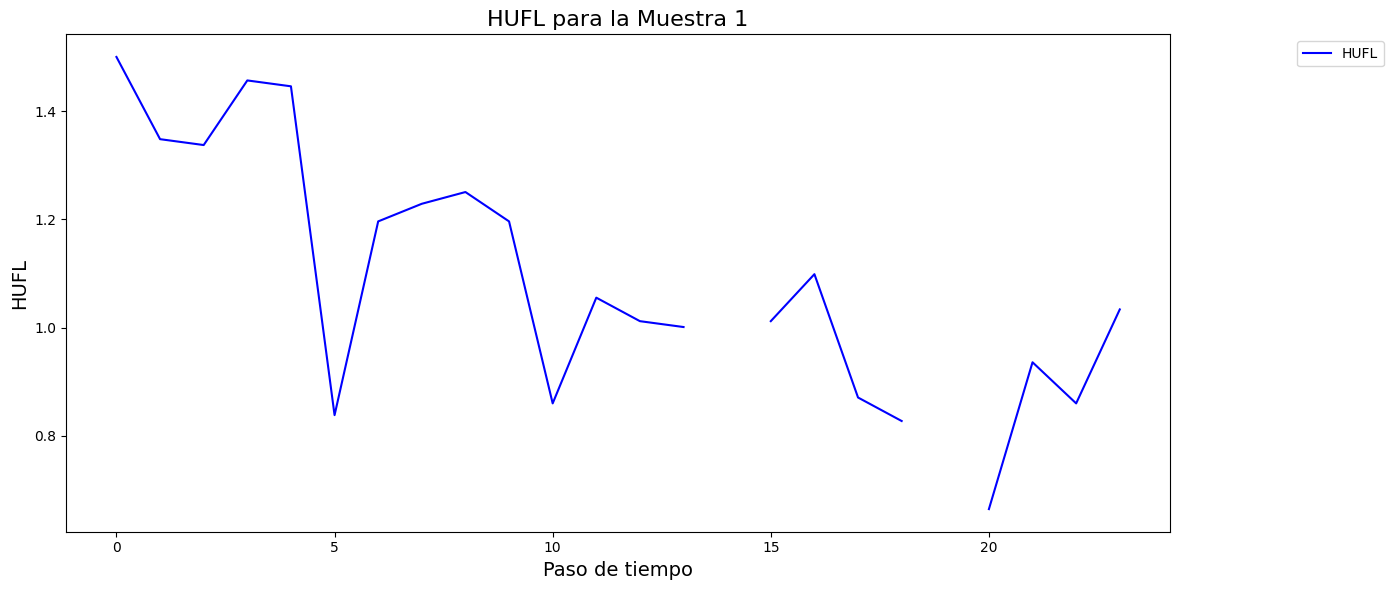

In [70]:
import matplotlib.pyplot as plt

# Seleccionar una muestra específica (por ejemplo, la primera muestra, índice 0)
sample_index = 0
time_steps = range(24)  # 24 pasos de tiempo

# Obtener los datos de la primera muestra para las características específicas
sample_data = df.loc[sample_index, ['HUFL', 'HULL']]

# Crear gráfico para MT_001
plt.figure(figsize=(14, 6))
if sample_data['HUFL'].notna().any():  # Verificar si hay datos válidos
    plt.plot(time_steps, sample_data['HUFL'], label='HUFL', color='b')
    plt.title(f'HUFL para la Muestra {sample_index + 1}', fontsize=16)
    plt.xlabel('Paso de tiempo', fontsize=14)
    plt.ylabel('HUFL', fontsize=14)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=10)
    plt.tight_layout()
else:
    print("No hay datos válidos para HUFL en la muestra.")



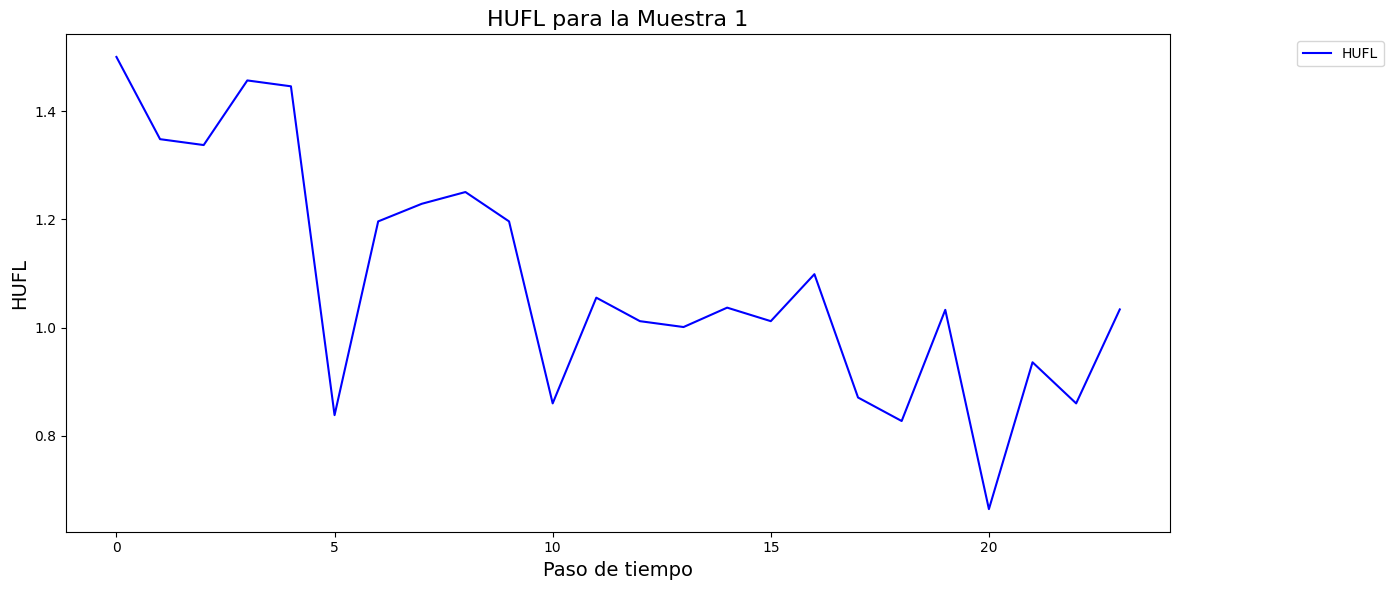

In [72]:
import matplotlib.pyplot as plt

# Seleccionar una muestra específica (por ejemplo, la primera muestra, índice 0)
sample_index = 0
time_steps = range(24)  # 24 pasos de tiempo

# Obtener los datos de la primera muestra para las características específicas
sample_data = df_imputation.loc[sample_index, ['HUFL', 'HULL']]

# Crear gráfico para Ritmo Cardíaco (HR)
plt.figure(figsize=(14, 6))
if sample_data['HUFL'].notna().any():  # Verificar si hay datos válidos
    plt.plot(time_steps, sample_data['HUFL'], label='HUFL', color='b')
    plt.title(f'HUFL para la Muestra {sample_index + 1}', fontsize=16)
    plt.xlabel('Paso de tiempo', fontsize=14)
    plt.ylabel('HUFL', fontsize=14)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=10)
    plt.tight_layout()
else:
    print("No hay datos válidos para HUFL en la muestra.")



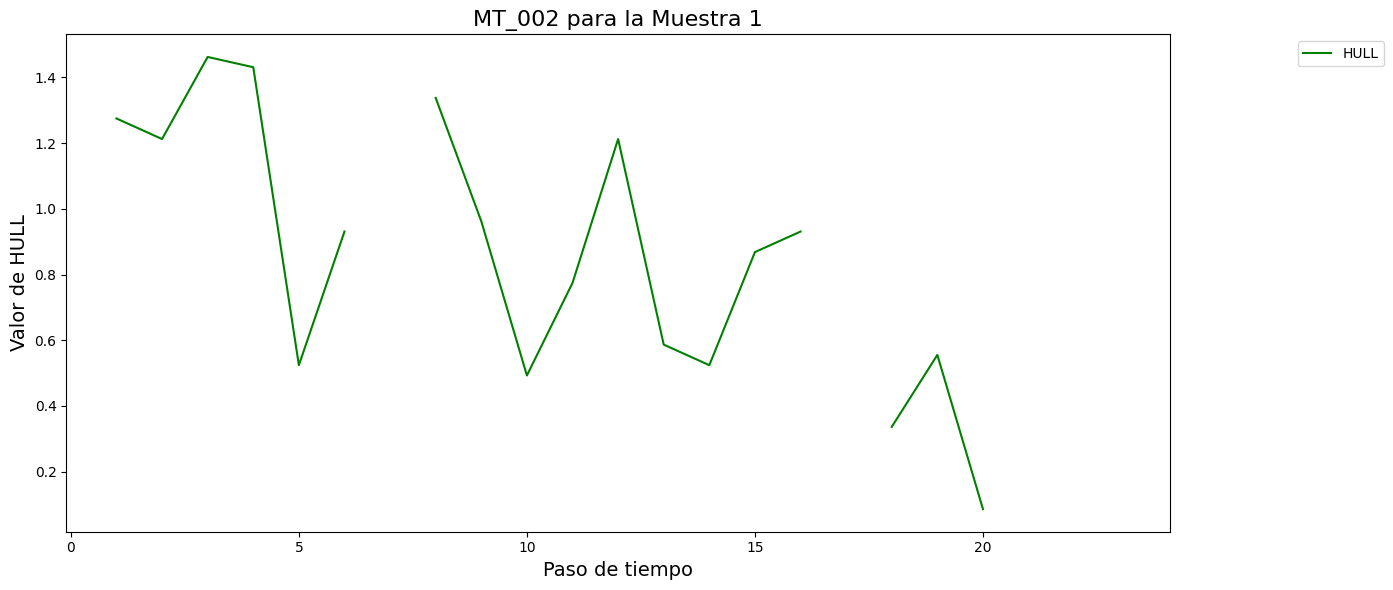

In [73]:
sample_data = df.loc[sample_index, ['HUFL', 'HULL']]

# Crear gráfico para Feature 0
plt.figure(figsize=(14, 6))
if sample_data['HULL'].notna().any():  # Verificar si hay datos válidos
    plt.plot(time_steps, sample_data['HULL'], label='HULL', color='g')
    plt.title(f'MT_002 para la Muestra {sample_index + 1}', fontsize=16)
    plt.xlabel('Paso de tiempo', fontsize=14)
    plt.ylabel('Valor de HULL', fontsize=14)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=10)
    plt.tight_layout()
else:
    print("No hay datos válidos para HULL en la muestra.")

# Mostrar los gráficos
plt.show()



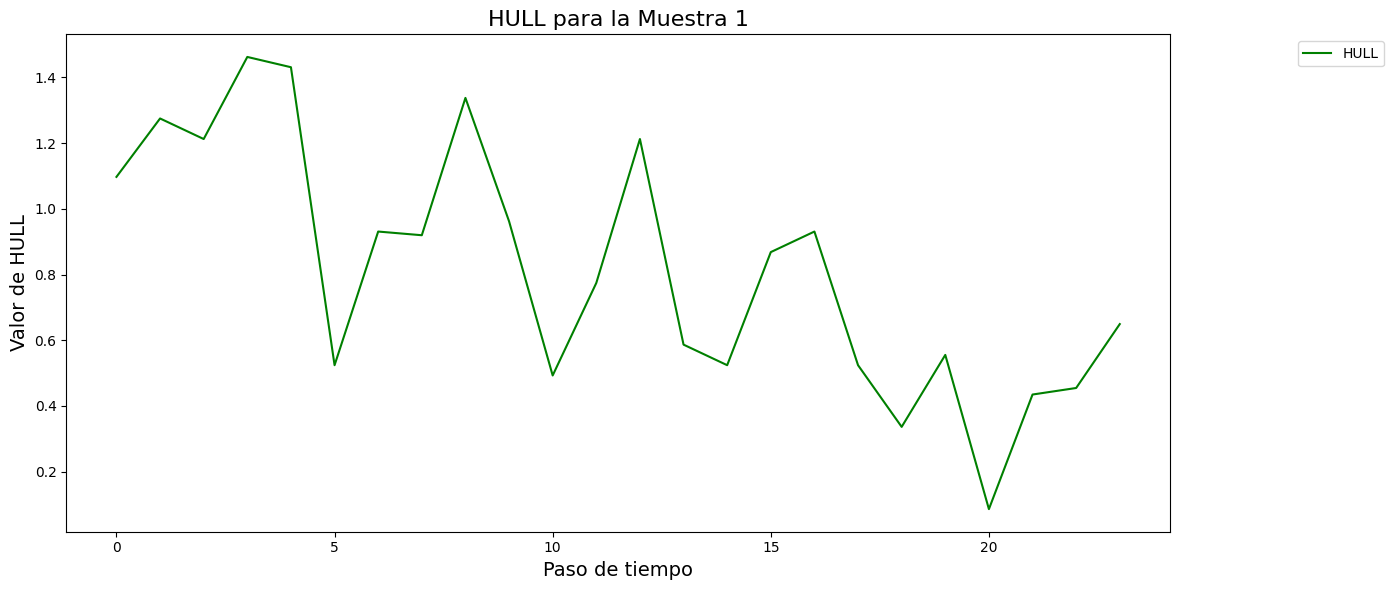

In [74]:
sample_data = df_imputation.loc[sample_index, ['HUFL', 'HULL']]

# Crear gráfico para Presión Arterial No Invasiva (NIMAP)
plt.figure(figsize=(14, 6))
if sample_data['HULL'].notna().any():  # Verificar si hay datos válidos
    plt.plot(time_steps, sample_data['HULL'], label='HULL', color='g')
    plt.title(f'HULL para la Muestra {sample_index + 1}', fontsize=16)
    plt.xlabel('Paso de tiempo', fontsize=14)
    plt.ylabel('Valor de HULL', fontsize=14)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=10)
    plt.tight_layout()
else:
    print("No hay datos válidos para HULL  en la muestra.")

# Mostrar los gráficos
plt.show()

In [75]:
saits_imputation.shape

(583, 24, 7)

In [76]:
from pypots.utils.metrics import calc_mae

ett['test_X_indicating_mask'] = np.isnan(ett['test_X']).astype(int)

# Crear una copia de los datos originales
test_X_ori_fixed = np.copy(ett['test_X_ori'])

# Reemplazar NaNs por 0 (valor constante)
test_X_ori_fixed[np.isnan(test_X_ori_fixed)] = 0

# Verificar si quedan NaNs
num_nans_fixed = np.isnan(test_X_ori_fixed).sum()
print(f"Número de NaNs en test_X_ori después de imputación (con 0): {num_nans_fixed}")

# calculate mean absolute error on the ground truth (artificially-missing values)
# predictions, targets, masks
testing_mae = calc_mae(
    saits_imputation, 
    test_X_ori_fixed, 
    ett['test_X_indicating_mask'],
)
print(f"Testing mean absolute error (MAE): {testing_mae:.4f}")

Número de NaNs en test_X_ori después de imputación (con 0): 0
Testing mean absolute error (MAE): 0.1423
